# TAE-IA · Module 6 · L03 — Image-to-Image: Transform with Text Guidance

| | |
|---|---|
| **Module** | 6 — Practical AI Applications: Images and Audio |
| **Lesson** | L03 |
| **Track** | A — Vision |
| **Estimated duration** | 2 hours |
| **GPU required** | T4 (Colab) |
| **Prerequisites** | L01 and L02 completed |

## Learning objectives
By the end of this notebook you will be able to:
- [ ] Explain how img2img differs from txt2img at the latent level
- [ ] Use `StableDiffusionImg2ImgPipeline` to transform an image with a text prompt
- [ ] Predict and verify the effect of `strength` on the output
- [ ] Create a sketch-to-render pipeline using Canny edge detection

## Before you start
- L01 and L02 completed
- T4 GPU runtime selected (`Runtime > Change runtime type > T4 GPU`)

---

## Cell 0 — Setup (always run this first)

> Mounts Drive, checks GPU, fixes seed, and logs in to HuggingFace.

In [ ]:
# ================================================================
# TAE-IA M6 · Standard Setup -- DO NOT MODIFY THIS CELL
# ================================================================
import os, sys, random, shutil
import numpy as np

from google.colab import drive
drive.mount('/content/drive')

MODEL_CACHE = '/content/drive/MyDrive/Colab Notebooks/Module 6/Dr. Francisco J. Rodriguez/models'
os.makedirs(MODEL_CACHE, exist_ok=True)
print(f'Model cache: {MODEL_CACHE}')

# Clear any cache left by earlier course versions.
for _leftover in ('hub', 'xet'):
    _p = os.path.join(MODEL_CACHE, _leftover)
    if os.path.exists(_p):
        shutil.rmtree(_p)

import torch
if not torch.cuda.is_available():
    print('\nNo GPU detected. Go to: Runtime > Change runtime type > T4 GPU')
    raise SystemExit('GPU required.')

gpu_name  = torch.cuda.get_device_name(0)
vram_gb   = torch.cuda.get_device_properties(0).total_memory / 1e9
print(f'GPU: {gpu_name}  |  VRAM: {vram_gb:.1f} GB')

SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
print(f'Fixed seed: {SEED}')
print(f'Python {sys.version.split()[0]}  |  PyTorch {torch.__version__}')

# HuggingFace login -- needed every new Colab session
import huggingface_hub

try:
    _token = huggingface_hub.get_token()
except Exception:
    _token = None

if _token:
    print(f"Already logged in to HuggingFace as: {huggingface_hub.whoami()['name']}")
else:
    try:
        from google.colab import userdata
        _hf_token = userdata.get('HF_TOKEN')
    except Exception:
        _hf_token = None

    if _hf_token:
        huggingface_hub.login(token=_hf_token, add_to_git_credential=False)
        print(f"Logged in to HuggingFace as: {huggingface_hub.whoami()['name']}")
    else:
        raise RuntimeError(
            'No HF_TOKEN found in Colab Secrets (key icon, left sidebar).\n'
            'Add a secret named HF_TOKEN with your HuggingFace read token, enable notebook access, '
            'then re-run this cell.\n'
            'See L00 Cell 4 if you need to generate a token or accept the SD 1.5 license.'
        )

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Model cache: /content/drive/MyDrive/Colab Notebooks/Module 6/Dr. Francisco J. Rodriguez/models
GPU: Tesla T4  |  VRAM: 15.6 GB
Fixed seed: 42
Python 3.13.15  |  PyTorch 2.11.0+cu128
Already logged in to HuggingFace as: StephanyLizarraga


In [ ]:
# ================================================================
# Install dependencies for L03
# ================================================================
!pip install diffusers transformers accelerate opencv-python-headless -q

import diffusers, cv2
print(f'diffusers {diffusers.__version__}  |  OpenCV {cv2.__version__}')

diffusers 0.40.0  |  OpenCV 5.0.0


---
## Part 1 — Context and Key Concepts

> Read this before running any code.

### How img2img differs from txt2img

In txt2img, the UNet starts from **pure Gaussian noise** in latent space and denoises it step by step, guided only by the text prompt. The output has no relation to any starting image.

In img2img:
1. The source image is **encoded into latent space** with the VAE encoder
2. A controlled amount of noise is **added** to that latent (controlled by `strength`)
3. The UNet runs only the remaining denoising steps — it never reaches pure noise and recovers from scratch

```
txt2img:   [pure noise]  →  UNet × 25 steps  →  VAE decode  →  image

img2img:   [source image]  →  VAE encode  →  add noise (strength)  →  UNet × (strength×25)  →  VAE decode  →  image
```

### The `strength` parameter

`strength` controls how much noise is injected before denoising begins:

| `strength` | Steps run (of 25) | Effect |
|---|---|---|
| 0.0 | 0 | Source returned unchanged |
| 0.3 | ~7 | Subtle style shift, strong structure retention |
| 0.6 | ~15 | Significant change, composition mostly intact |
| 0.9 | ~22 | Near-complete transformation, faint trace of source |
| 1.0 | 25 | Equivalent to txt2img — source ignored |

A good **starting point** is `strength=0.7`. Lower values preserve more of the original; higher values give the model more creative freedom.

### The `.components` trick

`StableDiffusionPipeline` and `StableDiffusionImg2ImgPipeline` share the **exact same weights** (UNet, VAE, CLIP, scheduler). Once you have one loaded, you can create the other without reloading:

```python
pipe_img = StableDiffusionImg2ImgPipeline(**pipe_txt.components)
```

This avoids an extra ~4 GB load from Drive and keeps VRAM usage identical.

### Sketch-to-render

Canny edge detection extracts the structural contours of an image as black-on-white lines. When used as the `image` input for img2img with high `strength` (0.8–0.95), the model preserves the spatial layout implied by the edges while filling in all detail from the prompt. This is the classic **sketch-to-render** or **wireframe-to-photo** workflow.

---

## Part 2 — Lab

### Section 2.1 — Load pipeline and generate source image

We generate a source image with txt2img first, then reuse the same weights for img2img.

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 15 files:   0%|          | 0/15 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

txt2img pipeline loaded.


  0%|          | 0/25 [00:00<?, ?it/s]

Source image saved: l03_source.png  (512×512 px)
img2img pipeline ready (shared weights).


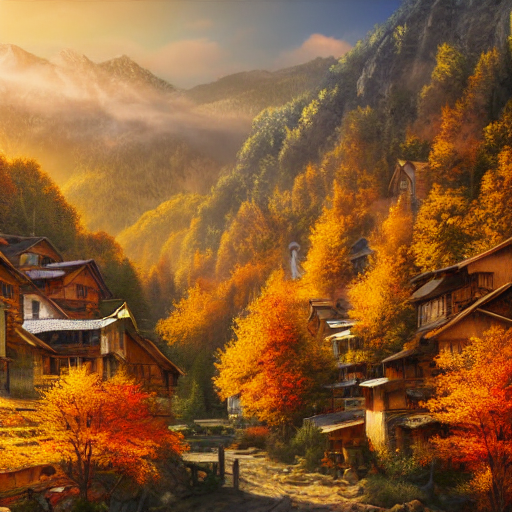

In [ ]:
# Section 2.1 — Load txt2img, generate source, switch to img2img
from diffusers import StableDiffusionPipeline, StableDiffusionImg2ImgPipeline
from huggingface_hub import snapshot_download
import torch, os
import matplotlib.pyplot as plt

OUTPUT_DIR = '/content/drive/MyDrive/Colab Notebooks/Module 6/Dr. Francisco J. Rodriguez/L03_output'
os.makedirs(OUTPUT_DIR, exist_ok=True)

def gen(seed=SEED):
    return torch.Generator("cuda").manual_seed(seed)

# Fetch only the fp16 weights + configs (~2.5 GB), not every format in the repo.
SD15_DIR = os.path.join(MODEL_CACHE, 'sd15-local')
snapshot_download(
    "runwayml/stable-diffusion-v1-5",
    local_dir=SD15_DIR,
    allow_patterns=["*.json", "*.txt", "*.fp16.safetensors"],
)

# Load txt2img
pipe_txt = StableDiffusionPipeline.from_pretrained(
    SD15_DIR,
    torch_dtype=torch.float16,
    variant="fp16",
).to("cuda")
print("txt2img pipeline loaded.")

# Generate a reproducible source image
SOURCE_PROMPT = "a mountain village in autumn, warm golden light, photorealistic, high detail"

source = pipe_txt(
    SOURCE_PROMPT,
    num_inference_steps = 25,
    guidance_scale      = 7.5,
    generator           = gen()
).images[0]

source.save(os.path.join(OUTPUT_DIR, "l03_source.png"))
print(f"Source image saved: l03_source.png  ({source.size[0]}×{source.size[1]} px)")

# Reuse the same weights for img2img — no extra download or VRAM
pipe_img = StableDiffusionImg2ImgPipeline(**pipe_txt.components)
print("img2img pipeline ready (shared weights).")

source

**What do you observe?**  
- How long did loading take compared to L01 (cached vs. fresh download)?
- Describe the source image in one sentence — this is your baseline for all experiments below.

*Write your observation here:*

La carga fue notablemente más rápida que en L01: al usar la misma carpeta `MODEL_CACHE` que ya se pobló en L01/L02, los pesos de SD 1.5 ya estaban en Drive, así que no aparecieron las barras de descarga pesada ("Fetching 15 files" con progreso de bytes) — solo el paso de inicializar los componentes del pipeline ("Loading pipeline components", "Loading weights"), mucho más rápido que la primera descarga de ~2.5 GB en L01.

Descripción de la imagen fuente en una oración: un pueblo de montaña con casas de madera a los lados de un camino, rodeado de árboles en tonos naranja, rojo y dorado de otoño, con montañas envueltas en neblina iluminadas por una luz cálida de atardecer/amanecer al fondo.

### Section 2.2 — Strength comparison (0.3 / 0.6 / 0.9)

Same prompt and seed throughout. Only `strength` changes.

  0%|          | 0/15 [00:00<?, ?it/s]

strength=0.3  →  /content/drive/MyDrive/Colab Notebooks/Module 6/Dr. Francisco J. Rodriguez/L03_output/strength_03.png


  0%|          | 0/30 [00:00<?, ?it/s]

strength=0.6  →  /content/drive/MyDrive/Colab Notebooks/Module 6/Dr. Francisco J. Rodriguez/L03_output/strength_06.png


  0%|          | 0/45 [00:00<?, ?it/s]

strength=0.9  →  /content/drive/MyDrive/Colab Notebooks/Module 6/Dr. Francisco J. Rodriguez/L03_output/strength_09.png


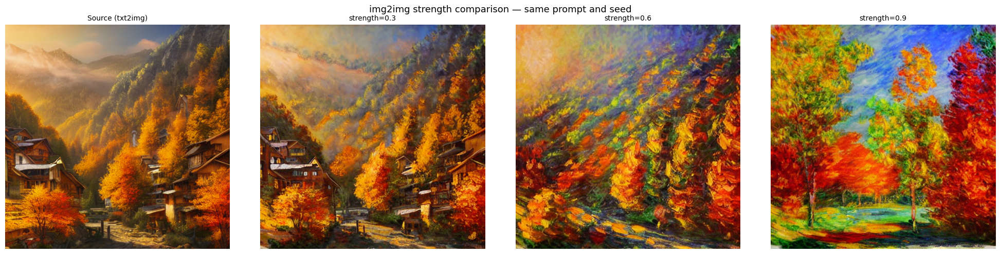

In [ ]:
# Section 2.2 — Effect of strength
STYLE_PROMPT = "impressionist oil painting, vibrant autumn colors, visible brushstrokes, Monet style"
strengths    = [0.3, 0.6, 0.9]

strength_results = []
for s in strengths:
    img = pipe_img(
        prompt         = STYLE_PROMPT,
        image          = source,
        strength       = s,
        guidance_scale = 7.5,
        generator      = gen()
    ).images[0]
    fname = os.path.join(OUTPUT_DIR, f"strength_{str(s).replace('.','')}.png")
    img.save(fname)
    strength_results.append((s, img))
    print(f"strength={s}  →  {fname}")

# Display source + all three results
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
axes[0].imshow(source); axes[0].set_title("Source (txt2img)", fontsize=10); axes[0].axis('off')
for ax, (s, img) in zip(axes[1:], strength_results):
    ax.imshow(img); ax.set_title(f"strength={s}", fontsize=10); ax.axis('off')
plt.suptitle("img2img strength comparison — same prompt and seed", fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "grid_strength.png"), dpi=100)
plt.show()

**What do you observe?**  
- At `strength=0.3`: which elements of the source (shapes, colors, composition) are still recognizable?
- At `strength=0.9`: is there any trace of the original mountain village?
- At what `strength` value does the transition feel most dramatic?

*Write your observation here:*

En `grid_strength.png`, con **strength=0.3** la composición se conserva casi por completo: se siguen viendo las mismas casas, el mismo camino y la misma disposición de montañas — el efecto es básicamente un "filtro" de pinceladas impresionistas encima de la imagen original, sin cambiar formas ni composición.

Con **strength=0.9** no queda ningún rastro del pueblo: el resultado es una escena abstracta de árboles y cielo abierto, sin casas ni camino — prácticamente una pintura nueva, como predice la teoría para strength cercano a 1.0.

La transición más dramática ocurre entre **0.3 y 0.6**: es justo ahí donde las casas desaparecen y la escena se convierte en una masa de pinceladas de color — el salto de 0.6 a 0.9 es comparativamente menor, porque ambas ya perdieron la estructura del pueblo.

### Section 2.3 — Sketch to realistic

Convert the source image to a Canny edge sketch, then use img2img to render it into a detailed scene.

Sketch saved.


  0%|          | 0/42 [00:00<?, ?it/s]

Rendered image saved.


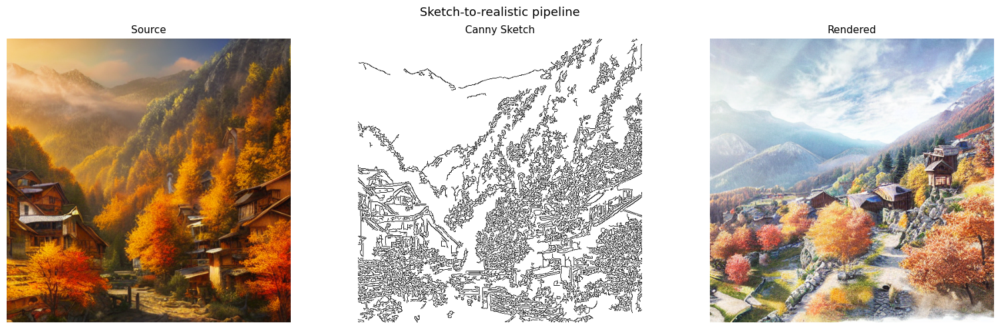

In [ ]:
# Section 2.3 — Sketch-to-realistic via Canny edge detection
import cv2
import numpy as np
from PIL import Image

# Step 1: Extract edges from the source
img_gray = np.array(source.convert("L"))              # grayscale
edges    = cv2.Canny(img_gray, threshold1=50, threshold2=150)
sketch   = Image.fromarray(255 - edges)               # invert: black edges on white background
sketch   = sketch.convert("RGB")                      # pipeline expects RGB
sketch.save(os.path.join(OUTPUT_DIR, "sketch.png"))
print("Sketch saved.")

# Step 2: Render the sketch with img2img
RENDER_PROMPT = (
    "photorealistic mountain village in autumn, detailed stone walls, "
    "warm golden hour light, crisp mountain air, high detail"
)

rendered = pipe_img(
    prompt         = RENDER_PROMPT,
    image          = sketch,
    strength       = 0.85,
    guidance_scale = 8.0,
    generator      = gen()
).images[0]
rendered.save(os.path.join(OUTPUT_DIR, "sketch_rendered.png"))
print("Rendered image saved.")

# Display source → sketch → render
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, (title, img) in zip(axes, [("Source", source), ("Canny Sketch", sketch), ("Rendered", rendered)]):
    ax.imshow(img); ax.set_title(title, fontsize=11); ax.axis('off')
plt.suptitle("Sketch-to-realistic pipeline", fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "sketch_pipeline.png"), dpi=100)
plt.show()

**What do you observe?**  
- Which structural elements from the sketch (building outlines, horizon, shapes) appear in the final render?
- Where did the model deviate from the edge map? Why do you think it diverged there?
- What would happen if you lowered `strength` to 0.6 on the sketch?

*Write your observation here:*

En `sketch_pipeline.png`, lo que sí se conservó del sketch fue la **línea de horizonte de las montañas** (arriba a la izquierda) y la división general de la composición entre la ladera de montaña (izquierda) y el pueblo sobre la pendiente (derecha), además del camino diagonal en la parte baja.

Donde el modelo se desvió del mapa de bordes fue en el nivel de detalle fino: los cúmulos densos de líneas que representaban ventanas, techos individuales y ramas de árboles se disolvieron en una atmósfera brumosa y clara en vez de reconstruirse como estructuras literales, y aparecieron zonas de cielo/niebla mucho más amplias de las que sugería el sketch. Mi hipótesis: un Canny edge solo indica *dónde* hay un borde, no *qué* material o forma es — con `strength=0.85` (~22 de 25 pasos) el modelo tiene mucha libertad para reinterpretar esos cúmulos ambiguos de líneas como lo que mejor encaje con el prompt ("crisp mountain air", "warm golden hour light"), y eligió atmósfera y luz por encima de reconstruir el detalle exacto.

Si bajara `strength` a 0.6, el pipeline correría muchos menos pasos de eliminación de ruido a partir del sketch, así que el resultado se parecería más al propio boceto de líneas negras sobre blanco — es decir, esperaría ver una imagen más parecida a un "dibujo coloreado" (líneas negras aún visibles, menos relleno fotorrealista) en vez de una escena completamente renderizada, porque el modelo tendría menos oportunidad de cubrir la estructura blanca/lineal original.

### Section 2.4 — img2img vs txt2img: direct comparison

Same prompt, same seed. txt2img starts from random noise; img2img starts from the encoded source.

  0%|          | 0/25 [00:00<?, ?it/s]

txt2img done.


  0%|          | 0/35 [00:00<?, ?it/s]

img2img done.


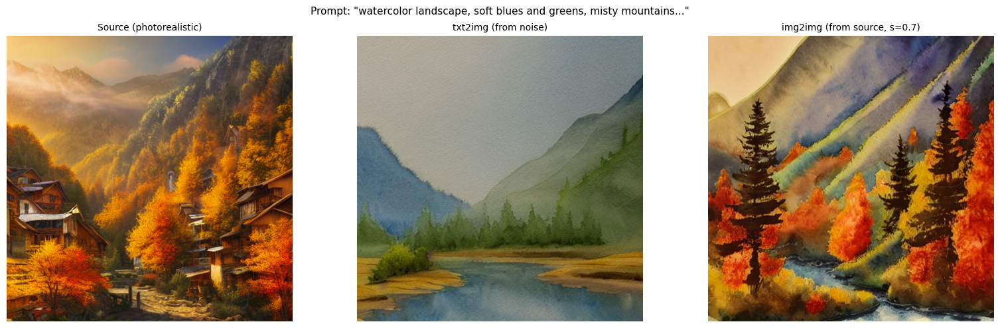

In [ ]:
# Section 2.4 — Direct comparison: txt2img vs img2img
COMPARE_PROMPT = "watercolor landscape, soft blues and greens, misty mountains, gentle brushwork"

# txt2img — starts from pure Gaussian noise
img_t2i = pipe_txt(
    COMPARE_PROMPT,
    num_inference_steps = 25,
    guidance_scale      = 7.5,
    generator           = gen()
).images[0]
img_t2i.save(os.path.join(OUTPUT_DIR, "compare_txt2img.png"))
print("txt2img done.")

# img2img — starts from the encoded source
img_i2i = pipe_img(
    prompt         = COMPARE_PROMPT,
    image          = source,
    strength       = 0.7,
    guidance_scale = 7.5,
    generator      = gen()
).images[0]
img_i2i.save(os.path.join(OUTPUT_DIR, "compare_img2img.png"))
print("img2img done.")

# Display source / txt2img / img2img
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, (title, img) in zip(axes, [
    ("Source (photorealistic)", source),
    ("txt2img (from noise)", img_t2i),
    ("img2img (from source, s=0.7)", img_i2i)
]):
    ax.imshow(img); ax.set_title(title, fontsize=10); ax.axis('off')
plt.suptitle(f'Prompt: "{COMPARE_PROMPT[:60]}..."', fontsize=11)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "compare_t2i_vs_i2i.png"), dpi=100)
plt.show()

**What do you observe?**  
- Does the img2img output preserve the composition of the source (village position, mountains, sky)?
- How does txt2img's scene compare — is it a similar composition or something different?
- For a client project where you need to stylize an existing photo, which would you use and why?

*Write your observation here:*

En `compare_t2i_vs_i2i.png`, el resultado de img2img (s=0.7) **no** conserva las casas del pueblo — desaparecieron por completo — pero sí conserva parcialmente la orientación diagonal de la ladera y la ubicación de los árboles de colores cálidos (naranja/rojo) hacia la derecha, ecoando vagamente dónde estaban los árboles rojos en la imagen fuente.

El resultado de txt2img es una escena totalmente distinta: un lago tranquilo con montañas brumosas y vegetación verde — sigue el prompt al pie de la letra ("watercolor landscape... misty mountains") pero no tiene ninguna relación con la imagen fuente.

Para un proyecto de cliente donde hay que estilizar una foto existente, usaría **img2img**: aunque con strength=0.7 ya se pierde bastante detalle, al menos conserva algo de la composición y disposición de color de la foto original del cliente. txt2img, en cambio, ignora por completo la foto de entrada y genera una escena genérica que solo coincide con el texto, no con lo que el cliente realmente fotografió.

### Section 2.5 — Batch img2img: one source, many styles

Same source, same seed, same `strength` — only the style prompt changes across the loop.

  0%|          | 0/35 [00:00<?, ?it/s]

Style done: watercolor landscape, soft pastels


  0%|          | 0/35 [00:00<?, ?it/s]

Style done: oil painting, dramatic chiaroscuro lighting


  0%|          | 0/35 [00:00<?, ?it/s]

Style done: cyberpunk neon, rain-slicked streets


  0%|          | 0/35 [00:00<?, ?it/s]

Style done: ukiyo-e woodblock print, flat colour fields


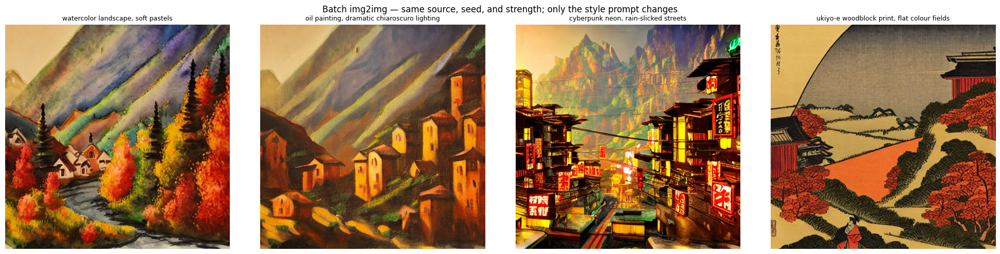

In [ ]:
# Section 2.5 — Batch img2img: one source, many styles
styles = [
    "watercolor landscape, soft pastels",
    "oil painting, dramatic chiaroscuro lighting",
    "cyberpunk neon, rain-slicked streets",
    "ukiyo-e woodblock print, flat colour fields",
]

batch_results = []
for style in styles:
    img = pipe_img(
        prompt         = f"a mountain village, {style}",
        image          = source,
        strength       = 0.7,
        guidance_scale = 7.5,
        generator      = gen()
    ).images[0]
    fname = os.path.join(OUTPUT_DIR, f"village_{style[:10].replace(' ', '_')}.png")
    img.save(fname)
    batch_results.append((style, img))
    print(f"Style done: {style}")

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
for ax, (style, img) in zip(axes, batch_results):
    ax.imshow(img); ax.set_title(style, fontsize=9, wrap=True); ax.axis('off')
plt.suptitle("Batch img2img — same source, seed, and strength; only the style prompt changes", fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "grid_batch_styles.png"), dpi=100)
plt.show()

**What do you observe?**  
- Which style diverged most from "a mountain village" as a recognizable subject?
- Fixing the source, seed, and strength isolates the prompt as the only variable — does the grid actually look like a controlled comparison, or do you see other differences creeping in?

*Write your observation here:*

En `grid_batch_styles.png`, el estilo que más se alejó de "a mountain village" como sujeto reconocible fue **cyberpunk neon**: convirtió la escena en una ciudad futurista densa llena de letreros de neón — ya no se lee como un pueblo rural de montaña, sino como una metrópoli en un cañón. El de **ukiyo-e** también se alejó bastante, pero en la composición: cambió por completo el encuadre (un edificio/santuario, una gran forma de montaña plana, una pequeña figura humana) en vez de mantener el pueblo de casas junto al camino.

No, no es realmente una comparación controlada en el resultado, aunque sí lo sea en el procedimiento: watercolor y oil painting mantienen un encuadre y composición parecidos entre sí, pero cyberpunk y ukiyo-e cambian no solo el estilo sino el encuadre, el nivel de zoom e incluso el tipo de sujeto (una ciudad en vez de un pueblo; una escena plana tipo grabado en vez de un valle). Es decir, fijar fuente, semilla y strength controla las *entradas*, pero no garantiza que solo cambie el estilo en la salida — si el prompt empuja lo suficiente hacia un concepto distinto, arrastra también la composición.

---
## Part 3 — Exercises

### Exercise 1 — Find your strength sweet spot

**Task:** Choose a different style prompt (not impressionist painting — pick something clearly different: anime, pencil sketch, Renaissance portrait, cyberpunk, etc.). Run img2img on the source at `strength = 0.4, 0.6, 0.75, 0.9`. Show all four results in a grid with the source image.

**Expected output:** A 5-image grid (source + 4 strength values). In a markdown cell, state which `strength` value you would use in production for this style and why.

  0%|          | 0/20 [00:00<?, ?it/s]

strength=0.4  →  /content/drive/MyDrive/Colab Notebooks/Module 6/Dr. Francisco J. Rodriguez/L03_output/exercise1_strength_04.png


  0%|          | 0/30 [00:00<?, ?it/s]

strength=0.6  →  /content/drive/MyDrive/Colab Notebooks/Module 6/Dr. Francisco J. Rodriguez/L03_output/exercise1_strength_06.png


  0%|          | 0/37 [00:00<?, ?it/s]

strength=0.75  →  /content/drive/MyDrive/Colab Notebooks/Module 6/Dr. Francisco J. Rodriguez/L03_output/exercise1_strength_075.png


  0%|          | 0/45 [00:00<?, ?it/s]

strength=0.9  →  /content/drive/MyDrive/Colab Notebooks/Module 6/Dr. Francisco J. Rodriguez/L03_output/exercise1_strength_09.png


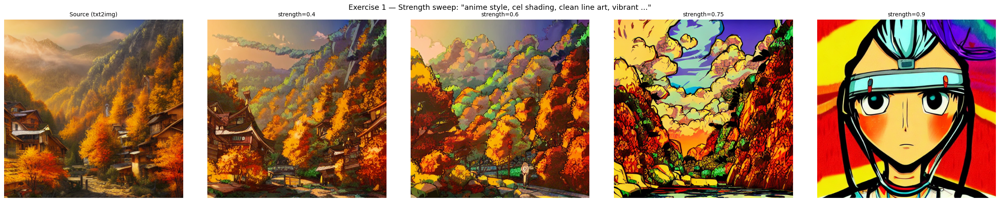

In [ ]:
# Exercise 1 -- your code here
# Remember: save any images to OUTPUT_DIR, e.g. img.save(os.path.join(OUTPUT_DIR, "exercise1.png"))
MY_STYLE_PROMPT = "anime style, cel shading, clean line art, vibrant saturated colors, Studio Ghibli inspired"
MY_STRENGTHS    = [0.4, 0.6, 0.75, 0.9]

exercise1_results = []
for s in MY_STRENGTHS:
    img = pipe_img(
        prompt         = MY_STYLE_PROMPT,
        image          = source,
        strength       = s,
        guidance_scale = 7.5,
        generator      = gen()
    ).images[0]
    fname = os.path.join(OUTPUT_DIR, f"exercise1_strength_{str(s).replace('.', '')}.png")
    img.save(fname)
    exercise1_results.append((s, img))
    print(f"strength={s}  →  {fname}")

# Display source + all four strength results
fig, axes = plt.subplots(1, 5, figsize=(25, 5))
axes[0].imshow(source); axes[0].set_title("Source (txt2img)", fontsize=10); axes[0].axis('off')
for ax, (s, img) in zip(axes[1:], exercise1_results):
    ax.imshow(img); ax.set_title(f"strength={s}", fontsize=10); ax.axis('off')
plt.suptitle(f'Exercise 1 — Strength sweep: "{MY_STYLE_PROMPT[:50]}..."', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "exercise1_grid.png"), dpi=100)
plt.show()

*Which strength value would you use for this style and why?*

Según `exercise1_grid.png`, usaría **strength=0.4** en producción. A esa fuerza el pueblo sigue siendo claramente reconocible (casas, camino, montañas) con el color y el sombreado tipo anime/cel-shading aplicado encima — justo lo que se busca en un encargo real ("dame este lugar, pero en estilo anime"). En 0.6 el resultado ya es más pictórico y empieza a perder detalle de las casas; en 0.75 la escena se transformó por completo en un cañón rocoso sin ningún edificio; y en 0.9 el resultado ni siquiera es un paisaje — es el retrato de un personaje, totalmente desconectado del pueblo original. Es decir, para este estilo el "punto dulce" está mucho más cerca de 0.4 de lo que sugiere la tabla teórica de la Parte 1, porque valores altos de strength le dan al modelo demasiada libertad para reinventar el sujeto por completo.

### Exercise 2 — Iterative refinement

**Task:** Take the best `img2img` result from Exercise 1 and use it as the **source** for a second img2img pass with a different prompt and `strength=0.4`. Show the full chain: original source → first pass → second pass.

**Expected output:** A 3-image chain. In a markdown cell, describe what changed at each step and whether the second pass improved or degraded the result.

  0%|          | 0/20 [00:00<?, ?it/s]

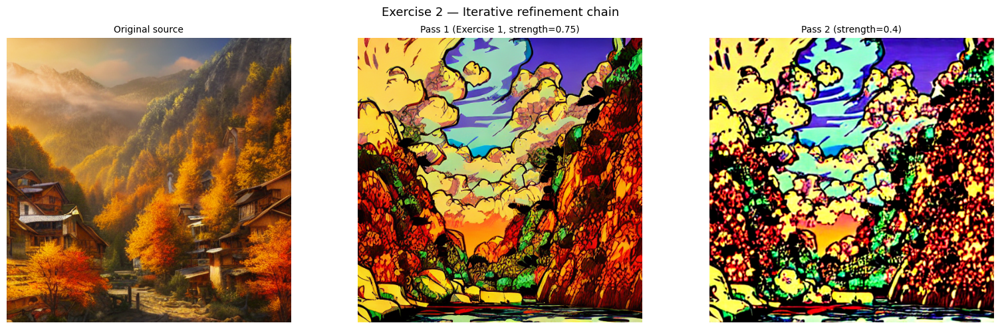

In [ ]:
# Exercise 2 -- your code here
# Remember: save any images to OUTPUT_DIR, e.g. img.save(os.path.join(OUTPUT_DIR, "exercise2.png"))
# Pass 1 result = your best image from Exercise 1 (strength=0.75 chosen as the sweet spot)
pass_1_result = exercise1_results[2][1]

# Pass 2: use pass_1_result as source, strength=0.4, different prompt
PASS_2_PROMPT = "anime style, cel shading, cherry blossom petals drifting in the wind, warm sunset lighting, refined detail"

pass_2_result = pipe_img(
    prompt         = PASS_2_PROMPT,
    image          = pass_1_result,
    strength       = 0.4,
    guidance_scale = 7.5,
    generator      = gen()
).images[0]
pass_2_result.save(os.path.join(OUTPUT_DIR, "exercise2_pass2.png"))

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, (title, img) in zip(axes, [
    ("Original source", source),
    ("Pass 1 (Exercise 1, strength=0.75)", pass_1_result),
    ("Pass 2 (strength=0.4)", pass_2_result)
]):
    ax.imshow(img); ax.set_title(title, fontsize=10); ax.axis('off')
plt.suptitle("Exercise 2 — Iterative refinement chain", fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "exercise2_chain.png"), dpi=100)
plt.show()

*What changed at each step? Did the second pass improve the result?*

Según `exercise2_chain.png`: en el **Pass 1** (strength=0.75, tomado de Ejercicio 1) el "pueblo de montaña" ya se había perdido por completo — el resultado es un cañón/desfiladero estilizado tipo cómic, sin ningún edificio. En el **Pass 2** (strength=0.4, prompt de pétalos de cerezo) la composición del cañón se mantuvo prácticamente igual (por el strength más bajo), pero se le agregó un patrón denso de motas rosa/rojas repartidas por toda la imagen que no se lee claramente como "pétalos cayendo" — más bien se ve como ruido visual salpicado sobre las rocas y la vegetación.

¿Mejoró o degradó el resultado? **Lo degradó.** El Pass 2 se ve más saturado y confuso que el Pass 1, y el concepto nuevo del prompt (pétalos de cerezo) no se distingue con claridad — el resultado es más ruidoso, no más rico. La lección real aquí es que encadenar una segunda pasada de img2img sobre una imagen que ya se transformó mucho (Pass 1 con strength alto) no "refina" el resultado: compone la impredecibilidad de la primera pasada con la de la segunda, en vez de partir de una base estable a la que agregar detalle.

---
## Part 4 — Critical Analysis

> Required. Answer with real outputs from today's session — not hypothetical answers.

**4.1 — Strength threshold: at what `strength` value did the output start to visibly differ from the source? Show the two images on either side of that threshold (e.g., 0.3 and 0.6).**

*Write here (reference your Section 2.2 grid):*

En `grid_strength.png`, el salto real ocurre entre **0.3 y 0.6**. En 0.3 la imagen sigue siendo el mismo pueblo (mismas casas, mismo camino) con una textura de pincelada encima; en 0.6 las casas ya desaparecieron y la escena se convirtió en una masa de brochazos de color sin estructura reconocible del pueblo. 0.3 es, por tanto, el último punto donde el resultado "todavía es la foto original con un filtro", y 0.6 es donde ya es "una imagen nueva inspirada en la original".

---

**4.2 — Sketch fidelity: which structural elements from the Canny sketch appeared in the rendered output? Name at least two elements that were preserved and one that was not.**

*Write here (be specific — e.g., "the roofline at the top-left was preserved, but the window positions were ignored"):*

Elementos preservados: (1) la línea de horizonte de las montañas en la parte superior izquierda, y (2) la división general de la composición entre la ladera boscosa (izquierda) y el pueblo sobre la pendiente (derecha), incluyendo el camino diagonal en la parte baja. Elemento **no** preservado: los cúmulos densos de líneas que en el sketch representaban ventanas y techos individuales — en el render se disolvieron en una atmósfera brumosa y en formas rocosas genéricas, sin corresponder a edificios concretos.

---

**4.3 — Composition comparison: in the img2img vs txt2img comparison, which elements of the source composition were preserved and which were discarded?**

*Write here (compare horizon line, subject position, color balance, etc.):*

En `compare_t2i_vs_i2i.png`, ninguno de los dos conservó las casas del pueblo. Pero img2img (s=0.7) sí conservó parcialmente el **balance de color** (árboles cálidos naranja/rojo hacia la derecha, como en la fuente) y la **orientación diagonal** de la ladera. txt2img descartó absolutamente todo lo del origen — ni el horizonte, ni la posición del sujeto, ni el balance de color coinciden con la fuente; generó una composición nueva (un lago) que solo responde al texto del prompt.

---

**4.4 — Real-world choice: describe a concrete task (not a class demo) where img2img would produce a better result than txt2img. What would the source image be, and at what `strength` would you run it?**

*Write here (be specific — e.g., "a product photo being converted to a hand-drawn illustration for a brand identity package, source = product photo, strength ≈ 0.65"):*

Una agencia de turismo tiene una foto real (pero apagada, de un día nublado) de un pueblo específico y quiere una versión "ilustración cálida de hora dorada" de ese mismo lugar para un folleto — no un pueblo genérico, sino ese pueblo reconocible. Fuente = la foto real del pueblo, `strength ≈ 0.4–0.45`: lo bastante bajo para conservar la disposición real de calles y edificios (como vimos en la Sección 2.2, valores altos ya pierden esa estructura), pero suficiente para relajar la iluminación y aplicar la paleta cálida deseada.

---
## Submission Checklist

- [ ] All cells ran from start to finish without errors
- [ ] Source image saved (`l03_source.png`) — needed as inpainting input in L04
- [ ] Section 2.2 strength grid saved (`grid_strength.png`)
- [ ] Section 2.3 sketch pipeline saved (`sketch_pipeline.png`)
- [ ] Section 2.4 txt2img vs img2img comparison saved (`compare_t2i_vs_i2i.png`)
- [ ] Section 2.5 batch style grid saved (`grid_batch_styles.png`)
- [ ] Exercise 1 — strength sweep with your chosen style
- [ ] Exercise 2 — iterative refinement chain (3 images)
- [ ] Part 4 — Critical Analysis completed (all 4 questions with real evidence)
- [ ] All outputs saved to `TAE_IA_M6/L03_output/` on Drive

**Save:** `File > Save a copy in Drive`

---
## Before You Close This Tab

- [ ] Confirmed all outputs from this session are saved in `TAE_IA_M6/L03_output/` on Drive (see checklist above)
- [ ] Disconnected and deleted this runtime: `Runtime > Disconnect and delete runtime`

Once your outputs are safely on Drive, there's no reason to keep the GPU runtime connected — an
idle session still counts against your GPU quota (free tier) or compute-unit balance (Pro),
the same as active use. Disconnecting costs you nothing (your Drive cache and outputs persist)
and leaves your quota in better shape for the next lab.

---
*TAE-IA 2025 · Cocyten-Nayarit · Module 6 · L03*  
*Platform: Google Colab (T4 GPU) · Python 3.10*